# Building the Transformer Decoder

Packages that are being used in this notebook:

In [1]:
from importlib.metadata import version

print("torch version:", version("torch"))
print("matplotlib version:", version("matplotlib"))
print("numpy version:", version("numpy"))

torch version: 2.8.0
matplotlib version: 3.10.8
numpy version: 2.3.2


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(123)

- In the previous notebooks, we covered **tokenization & embeddings** (Chapter 1), **attention mechanisms** (Chapter 2), and the **Transformer Encoder** (Chapter 3)
- Now we build the **Transformer Decoder** — the generative half of the original Transformer architecture
- The decoder is used in models like **GPT**, **LLaMA**, and the decoder side of sequence-to-sequence models like **T5** and the original Transformer

## Overview: What is the Transformer Decoder?

- The Transformer Decoder generates output tokens **one at a time**, left-to-right
- Unlike the encoder (bidirectional), the decoder uses **causal (masked) attention** — each token can only attend to itself and past tokens, not future ones
- In the full encoder-decoder architecture, the decoder has **three sub-layers** per block:
  1. **Masked Multi-Head Self-Attention** — attends only to previous decoder tokens
  2. **Cross-Attention (Encoder-Decoder Attention)** — queries from decoder, keys/values from encoder
  3. **Position-wise Feed-Forward Network** — same as the encoder
- Each sub-layer has a **residual connection** and **layer normalization**
- A **decoder-only** variant (used in GPT) removes cross-attention entirely

Let's visualize both the full decoder block and the decoder-only (GPT-style) block:

/var/folders/xg/pf411g390wqfjs0pn97zr8cw0000gn/T/ipykernel_20951/3342615132.py:102: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/lm/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


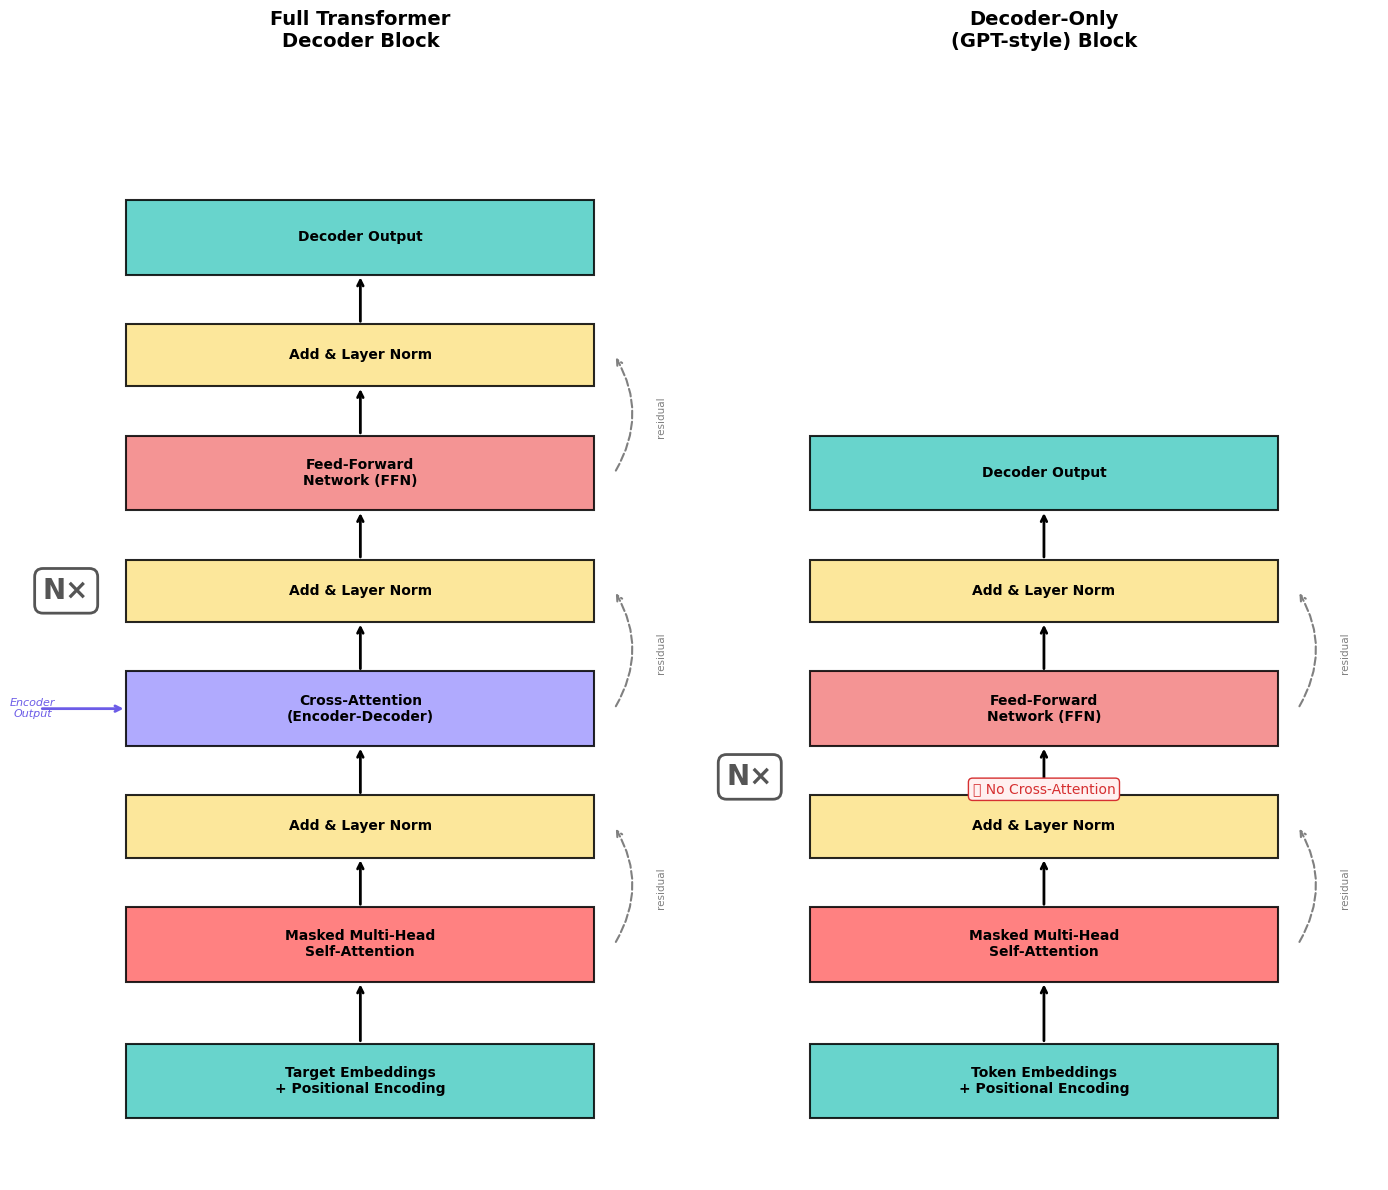

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 12))

colors = {
    'input':   '#4ECDC4',
    'self_attn': '#FF6B6B',
    'cross_attn': '#A29BFE',
    'norm':    '#95E1D3',
    'ffn':     '#F38181',
    'add':     '#FCE38A',
    'output':  '#4ECDC4',
    'enc':     '#DFE6E9',
}

# ── Left: Full Encoder-Decoder Decoder Block ─────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 18)
ax.axis("off")
ax.set_title("Full Transformer\nDecoder Block", fontsize=14, fontweight="bold", pad=12)

blocks_left = [
    (1.5,  1.0, 7, 1.2, "Target Embeddings\n+ Positional Encoding", colors["input"]),
    (1.5,  3.2, 7, 1.2, "Masked Multi-Head\nSelf-Attention",         colors["self_attn"]),
    (1.5,  5.2, 7, 1.0, "Add & Layer Norm",                          colors["add"]),
    (1.5,  7.0, 7, 1.2, "Cross-Attention\n(Encoder-Decoder)",        colors["cross_attn"]),
    (1.5,  9.0, 7, 1.0, "Add & Layer Norm",                          colors["add"]),
    (1.5, 10.8, 7, 1.2, "Feed-Forward\nNetwork (FFN)",               colors["ffn"]),
    (1.5, 12.8, 7, 1.0, "Add & Layer Norm",                          colors["add"]),
    (1.5, 14.6, 7, 1.2, "Decoder Output",                            colors["output"]),
]

for x, y, w, h, label, color in blocks_left:
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor="black", linewidth=1.5, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=10, fontweight="bold")

# Arrows (main flow)
arrow_props = dict(arrowstyle="->", color="black", lw=2)
ax_x = 5.0
for y_start, y_end in [(2.2, 3.2), (4.4, 5.2), (6.2, 7.0), (8.2, 9.0), (10.0, 10.8), (12.0, 12.8), (13.8, 14.6)]:
    ax.annotate("", xy=(ax_x, y_end), xytext=(ax_x, y_start), arrowprops=arrow_props)

# Residual skip connections
for res_start, res_end in [(3.2, 5.2), (7.0, 9.0), (10.8, 12.8)]:
    ax.annotate("", xy=(8.8, res_end + 0.5), xytext=(8.8, res_start + 0.6),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.5,
                               connectionstyle="arc3,rad=0.3", linestyle="--"))
    ax.text(9.5, (res_start + res_end) / 2 + 0.5, "residual", fontsize=7.5,
            color="gray", rotation=90, ha="center", va="center")

# Encoder memory arrow into cross-attention
ax.annotate("", xy=(1.5, 7.6), xytext=(0.2, 7.6),
            arrowprops=dict(arrowstyle="->", color="#6C5CE7", lw=2))
ax.text(0.1, 7.6, "Encoder\nOutput", fontsize=8, color="#6C5CE7",
        ha="center", va="center", fontstyle="italic")

# Nx label
ax.text(0.6, 9.5, "N×", fontsize=20, fontweight="bold", color="#555",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#555", linewidth=2))

# ── Right: Decoder-Only (GPT-style) Block ────────────────────────────────
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 18)
ax2.axis("off")
ax2.set_title("Decoder-Only\n(GPT-style) Block", fontsize=14, fontweight="bold", pad=12)

blocks_right = [
    (1.5,  1.0, 7, 1.2, "Token Embeddings\n+ Positional Encoding", colors["input"]),
    (1.5,  3.2, 7, 1.2, "Masked Multi-Head\nSelf-Attention",        colors["self_attn"]),
    (1.5,  5.2, 7, 1.0, "Add & Layer Norm",                         colors["add"]),
    (1.5,  7.0, 7, 1.2, "Feed-Forward\nNetwork (FFN)",              colors["ffn"]),
    (1.5,  9.0, 7, 1.0, "Add & Layer Norm",                         colors["add"]),
    (1.5, 10.8, 7, 1.2, "Decoder Output",                           colors["output"]),
]

for x, y, w, h, label, color in blocks_right:
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor="black", linewidth=1.5, alpha=0.85)
    ax2.add_patch(rect)
    ax2.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=10, fontweight="bold")

for y_start, y_end in [(2.2, 3.2), (4.4, 5.2), (6.2, 7.0), (8.2, 9.0), (10.0, 10.8)]:
    ax2.annotate("", xy=(ax_x, y_end), xytext=(ax_x, y_start), arrowprops=arrow_props)

for res_start, res_end in [(3.2, 5.2), (7.0, 9.0)]:
    ax2.annotate("", xy=(8.8, res_end + 0.5), xytext=(8.8, res_start + 0.6),
                 arrowprops=dict(arrowstyle="->", color="gray", lw=1.5,
                                connectionstyle="arc3,rad=0.3", linestyle="--"))
    ax2.text(9.5, (res_start + res_end) / 2 + 0.5, "residual", fontsize=7.5,
             color="gray", rotation=90, ha="center", va="center")

# No cross-attention label
ax2.text(5, 6.3, "❌ No Cross-Attention", ha="center", va="center",
         fontsize=10, color="#d63031",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="#fff0f0", edgecolor="#d63031"))

ax2.text(0.6, 6.5, "N×", fontsize=20, fontweight="bold", color="#555",
         ha="center", va="center",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#555", linewidth=2))

plt.tight_layout()
plt.show()

- We will build each component **from scratch**, step by step
- At the end, we will assemble them into a complete **Transformer Decoder** and a **GPT-style decoder-only** model
- We will visualize each component to build deep intuition

---

## 1. Input Embeddings + Positional Encoding (Recap)

- We covered sinusoidal positional encoding in depth in Chapter 3 (Encoder)
- The decoder uses the **same positional encoding** scheme for its input (target) sequence
- In training, the decoder receives the **shifted-right** target sequence (teacher forcing)
- In inference, it receives the tokens generated so far

In [4]:
class SinusoidalPositionalEncoding(nn.Module):
    """Sinusoidal positional encoding from 'Attention Is All You Need'."""

    def __init__(self, d_model, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, d_model)  # (max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # (max_len, 1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )  # (d_model/2,)

        pe[:, 0::2] = torch.sin(position * div_term)  # even indices
        pe[:, 1::2] = torch.cos(position * div_term)  # odd indices

        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        return x + self.pe[:, :x.size(1), :]

- This is identical to the encoder version — the same sinusoidal encoding applies to both source and target sequences
- The positional encoding is **not learned** — it is fixed and deterministic

---

## 2. Masked Multi-Head Self-Attention

- This is the **first and most critical difference** between the encoder and decoder
- The encoder uses **bidirectional** attention (every token sees all others)
- The decoder uses **causal (autoregressive) attention** — each token can only see itself and **previous** tokens
- This constraint is enforced by a **causal mask** that zeroes out attention to future positions
- **Why?** During generation, we do not have access to future tokens. Even during training, we mask them to simulate inference conditions

### 2.1 The Causal (Look-Ahead) Mask

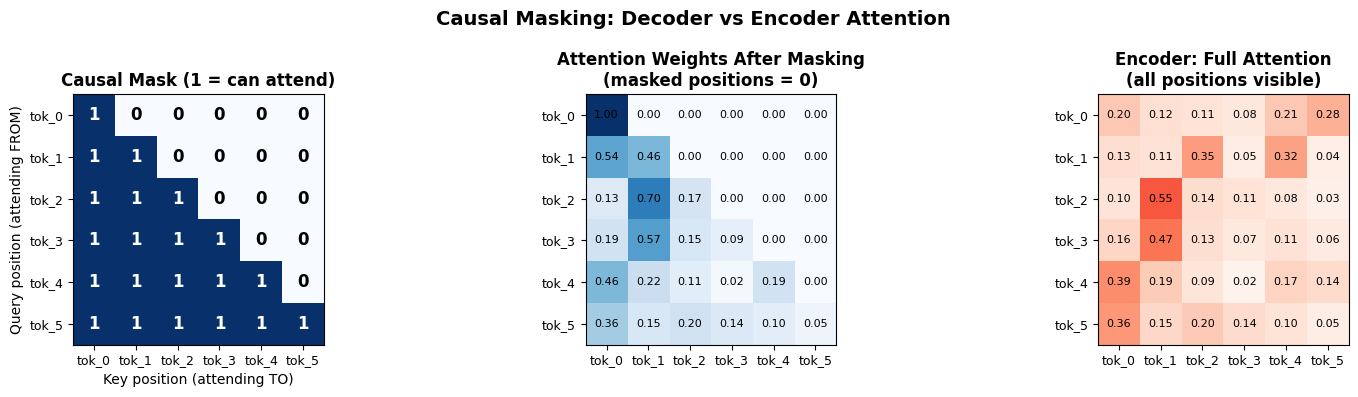

Causal mask (lower-triangular):
tensor([[1, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1]], dtype=torch.int32)


In [5]:
# The causal mask is a lower-triangular matrix of 1s
# Position (i, j) = 1 means token i CAN attend to token j
# Position (i, j) = 0 means token i CANNOT attend to token j (future position)

seq_len = 6
causal_mask = torch.tril(torch.ones(seq_len, seq_len))  # lower triangle

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: The binary mask
axes[0].imshow(causal_mask.numpy(), cmap="Blues", vmin=0, vmax=1)
axes[0].set_title("Causal Mask (1 = can attend)", fontsize=12, fontweight="bold")
for i in range(seq_len):
    for j in range(seq_len):
        val = int(causal_mask[i, j].item())
        axes[0].text(j, i, str(val), ha="center", va="center", fontsize=12,
                     color="white" if val == 1 else "black", fontweight="bold")
axes[0].set_xlabel("Key position (attending TO)")
axes[0].set_ylabel("Query position (attending FROM)")
axes[0].set_xticks(range(seq_len))
axes[0].set_yticks(range(seq_len))
axes[0].set_xticklabels([f"tok_{i}" for i in range(seq_len)], fontsize=9)
axes[0].set_yticklabels([f"tok_{i}" for i in range(seq_len)], fontsize=9)

# Plot 2: How the mask is applied to attention scores
# Scores get -inf where mask==0, so softmax gives 0 probability to future tokens
sample_scores = torch.randn(seq_len, seq_len)
mask_fill = causal_mask == 0
masked_scores = sample_scores.masked_fill(mask_fill, float("-inf"))
attn_weights = torch.softmax(masked_scores, dim=-1)

axes[1].imshow(attn_weights.detach().numpy(), cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Attention Weights After Masking\n(masked positions = 0)", fontsize=12, fontweight="bold")
for i in range(seq_len):
    for j in range(seq_len):
        val = attn_weights[i, j].item()
        axes[1].text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
axes[1].set_xticks(range(seq_len))
axes[1].set_yticks(range(seq_len))
axes[1].set_xticklabels([f"tok_{i}" for i in range(seq_len)], fontsize=9)
axes[1].set_yticklabels([f"tok_{i}" for i in range(seq_len)], fontsize=9)

# Plot 3: Encoder (full) vs Decoder (causal) comparison
full_weights = torch.softmax(sample_scores, dim=-1)
axes[2].imshow(full_weights.detach().numpy(), cmap="Reds", vmin=0, vmax=1)
axes[2].set_title("Encoder: Full Attention\n(all positions visible)", fontsize=12, fontweight="bold")
for i in range(seq_len):
    for j in range(seq_len):
        val = full_weights[i, j].item()
        axes[2].text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
axes[2].set_xticks(range(seq_len))
axes[2].set_yticks(range(seq_len))
axes[2].set_xticklabels([f"tok_{i}" for i in range(seq_len)], fontsize=9)
axes[2].set_yticklabels([f"tok_{i}" for i in range(seq_len)], fontsize=9)

plt.suptitle("Causal Masking: Decoder vs Encoder Attention", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Causal mask (lower-triangular):")
print(causal_mask.int())

- **Left**: The mask is a lower-triangular matrix — 1s below (and on) the diagonal, 0s above
- **Middle**: After applying the mask, future positions get weight 0 — the decoder cannot "peek ahead"
- **Right**: The encoder has no mask — every token freely attends to every other token
- Row `i` of the attention matrix represents what token `i` attends to
  - In the decoder, `tok_3` can only attend to `tok_0`, `tok_1`, `tok_2`, and itself

### 2.2 Implementing Masked Multi-Head Self-Attention

In [6]:
class MaskedMultiHeadSelfAttention(nn.Module):
    """Masked Multi-Head Self-Attention for the Decoder.
    Uses a causal mask so each position can only attend to itself and earlier positions.
    """

    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        # Linear projections for Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # Output projection
        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model) — decoder's own representations
        batch_size, seq_len, d_model = x.shape

        # Step 1: Linear projections
        Q = self.W_q(x)  # (batch, seq_len, d_model)
        K = self.W_k(x)
        V = self.W_v(x)

        # Step 2: Reshape into multiple heads
        # (batch, seq_len, d_model) -> (batch, num_heads, seq_len, head_dim)
        Q = Q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        # Step 3: Scaled dot-product attention
        attn_scores = Q @ K.transpose(-2, -1)           # (batch, heads, seq_len, seq_len)
        attn_scores = attn_scores / (self.head_dim ** 0.5)  # scale

        # Step 4: Apply causal mask
        # Create a lower-triangular mask: True where we WANT to keep scores
        causal_mask = torch.tril(torch.ones(seq_len, seq_len, device=x.device)).bool()
        # Fill upper triangle with -inf so softmax gives 0 probability
        attn_scores = attn_scores.masked_fill(~causal_mask, float("-inf"))

        # Step 5: Softmax + dropout
        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Step 6: Weighted sum of values
        context = attn_weights @ V  # (batch, heads, seq_len, head_dim)

        # Step 7: Concatenate heads and project
        context = context.transpose(1, 2).contiguous()       # (batch, seq_len, heads, head_dim)
        context = context.view(batch_size, seq_len, d_model)  # (batch, seq_len, d_model)
        output = self.W_o(context)

        return output, attn_weights

- The **only difference** from encoder self-attention is the causal mask applied at Step 4
- `masked_fill(~causal_mask, float("-inf"))` — positions above the diagonal get `-inf` before softmax
- After softmax, `-inf` becomes exactly `0.0` — those positions contribute nothing to the output

In [7]:
# Test masked self-attention
torch.manual_seed(123)

d_model = 64
num_heads = 4
seq_len = 6
batch_size = 2

masked_attn = MaskedMultiHeadSelfAttention(d_model, num_heads)

x = torch.randn(batch_size, seq_len, d_model)
output, attn_weights = masked_attn(x)

print(f"Input shape:          {x.shape}")
print(f"Output shape:         {output.shape}")
print(f"Attention weights:    {attn_weights.shape}  (batch, heads, seq, seq)")

# Verify causality: upper triangle should be exactly 0
weights_head0 = attn_weights[0, 0].detach()  # first batch, first head
upper_triangle_sum = weights_head0.triu(diagonal=1).sum().item()
print(f"\nUpper triangle sum (should be 0.0): {upper_triangle_sum:.6f}")
print("Causality constraint verified: future positions have 0 attention weight")

Input shape:          torch.Size([2, 6, 64])
Output shape:         torch.Size([2, 6, 64])
Attention weights:    torch.Size([2, 4, 6, 6])  (batch, heads, seq, seq)

Upper triangle sum (should be 0.0): 0.000000
Causality constraint verified: future positions have 0 attention weight


### 2.3 Visualizing Masked Attention Patterns

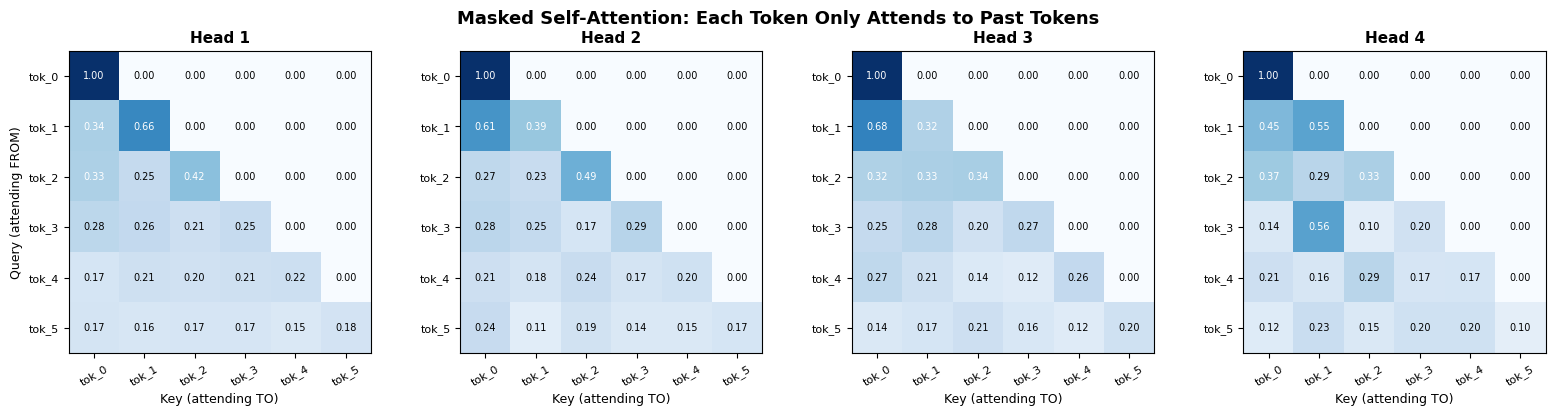

In [8]:
fig, axes = plt.subplots(1, num_heads, figsize=(16, 4))

token_labels = [f"tok_{i}" for i in range(seq_len)]

for head_idx in range(num_heads):
    ax = axes[head_idx]
    weights = attn_weights[0, head_idx].detach().numpy()

    im = ax.imshow(weights, cmap="Blues", vmin=0, vmax=weights.max())
    ax.set_title(f"Head {head_idx + 1}", fontsize=11, fontweight="bold")

    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels(token_labels, fontsize=8, rotation=30)
    ax.set_yticklabels(token_labels, fontsize=8)

    for i in range(seq_len):
        for j in range(seq_len):
            val = weights[i, j]
            color = "white" if val > 0.3 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=color)

    if head_idx == 0:
        ax.set_ylabel("Query (attending FROM)", fontsize=9)
    ax.set_xlabel("Key (attending TO)", fontsize=9)

plt.suptitle("Masked Self-Attention: Each Token Only Attends to Past Tokens",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

- The lower-triangular structure is clearly visible — the upper right is always zero
- `tok_0` (first row) can only attend to itself
- `tok_5` (last row) can attend to all six positions
- Different heads learn **different weighting patterns** within the causal constraint

---

## 3. Cross-Attention (Encoder-Decoder Attention)

- Cross-attention is the **bridge between encoder and decoder**
- In self-attention, Q, K, V all come from the same sequence
- In cross-attention:
  - **Q (Queries)** come from the **decoder** (what the decoder is looking for)
  - **K (Keys) and V (Values)** come from the **encoder output** (what the encoder has seen)
- This lets the decoder "look up" relevant parts of the input sequence at each decoding step
- There is **no causal mask** here — the decoder can attend to any encoder position freely
- Think of it as: the decoder asking "which parts of the source sentence should I focus on right now?"

### 3.1 How Cross-Attention Differs from Self-Attention

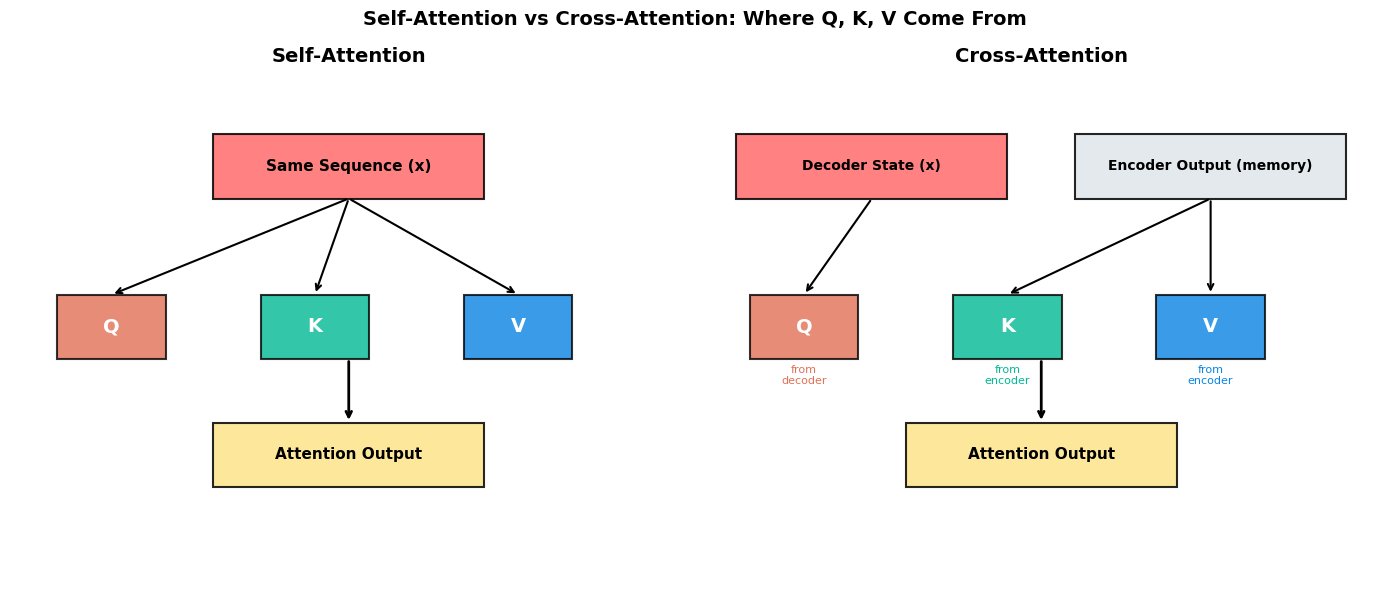

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Self-Attention ─────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis("off")
ax.set_title("Self-Attention", fontsize=14, fontweight="bold")

# Single input source
rect = plt.Rectangle((3, 6), 4, 1, facecolor="#FF6B6B", edgecolor="black", linewidth=1.5, alpha=0.85)
ax.add_patch(rect)
ax.text(5, 6.5, "Same Sequence (x)", ha="center", va="center", fontsize=11, fontweight="bold")

# Q, K, V all from same source
for x_pos, label, col in [(1.5, "Q", "#E17055"), (4.5, "K", "#00B894"), (7.5, "V", "#0984E3")]:
    rect2 = plt.Rectangle((x_pos - 0.8, 3.5), 1.6, 1, facecolor=col, edgecolor="black", linewidth=1.5, alpha=0.8)
    ax.add_patch(rect2)
    ax.text(x_pos, 4.0, label, ha="center", va="center", fontsize=14, fontweight="bold", color="white")
    ax.annotate("", xy=(x_pos, 4.5), xytext=(5, 6),
                arrowprops=dict(arrowstyle="->", color="black", lw=1.5))

# Attention output
rect3 = plt.Rectangle((3, 1.5), 4, 1, facecolor="#FCE38A", edgecolor="black", linewidth=1.5, alpha=0.85)
ax.add_patch(rect3)
ax.text(5, 2.0, "Attention Output", ha="center", va="center", fontsize=11, fontweight="bold")
ax.annotate("", xy=(5, 2.5), xytext=(5, 3.5),
            arrowprops=dict(arrowstyle="->", color="black", lw=2))

# ── Right: Cross-Attention ───────────────────────────────────────────────
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 8)
ax2.axis("off")
ax2.set_title("Cross-Attention", fontsize=14, fontweight="bold")

# Two input sources
rect_enc = plt.Rectangle((5.5, 6), 4, 1, facecolor="#DFE6E9", edgecolor="black", linewidth=1.5, alpha=0.85)
ax2.add_patch(rect_enc)
ax2.text(7.5, 6.5, "Encoder Output (memory)", ha="center", va="center", fontsize=10, fontweight="bold")

rect_dec = plt.Rectangle((0.5, 6), 4, 1, facecolor="#FF6B6B", edgecolor="black", linewidth=1.5, alpha=0.85)
ax2.add_patch(rect_dec)
ax2.text(2.5, 6.5, "Decoder State (x)", ha="center", va="center", fontsize=10, fontweight="bold")

# Q from decoder, K and V from encoder
for x_pos, label, col, src_x in [
        (1.5, "Q", "#E17055", 2.5),
        (4.5, "K", "#00B894", 7.5),
        (7.5, "V", "#0984E3", 7.5)]:
    rect2 = plt.Rectangle((x_pos - 0.8, 3.5), 1.6, 1, facecolor=col, edgecolor="black", linewidth=1.5, alpha=0.8)
    ax2.add_patch(rect2)
    ax2.text(x_pos, 4.0, label, ha="center", va="center", fontsize=14, fontweight="bold", color="white")
    ax2.annotate("", xy=(x_pos, 4.5), xytext=(src_x, 6),
                arrowprops=dict(arrowstyle="->", color="black", lw=1.5))

# Attention output
rect3 = plt.Rectangle((3, 1.5), 4, 1, facecolor="#FCE38A", edgecolor="black", linewidth=1.5, alpha=0.85)
ax2.add_patch(rect3)
ax2.text(5, 2.0, "Attention Output", ha="center", va="center", fontsize=11, fontweight="bold")
ax2.annotate("", xy=(5, 2.5), xytext=(5, 3.5),
             arrowprops=dict(arrowstyle="->", color="black", lw=2))

# Annotations
ax2.text(1.5, 3.1, "from\ndecoder", ha="center", fontsize=8, color="#E17055")
ax2.text(4.5, 3.1, "from\nencoder", ha="center", fontsize=8, color="#00B894")
ax2.text(7.5, 3.1, "from\nencoder", ha="center", fontsize=8, color="#0984E3")

plt.suptitle("Self-Attention vs Cross-Attention: Where Q, K, V Come From",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.2 Implementing Cross-Attention

In [10]:
class CrossAttention(nn.Module):
    """Cross-Attention (Encoder-Decoder Attention).
    Queries come from the decoder; Keys and Values come from the encoder output.
    No causal mask — the decoder can freely attend to all encoder positions.
    """

    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        # Q projection: maps decoder state -> queries
        self.W_q = nn.Linear(d_model, d_model)
        # K, V projections: map encoder output -> keys/values
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, encoder_output):
        # x:              (batch, tgt_len, d_model)  — decoder state
        # encoder_output: (batch, src_len, d_model)  — encoder memory
        batch_size, tgt_len, _ = x.shape
        _, src_len, _          = encoder_output.shape

        # Step 1: Q from decoder state; K, V from encoder output
        Q = self.W_q(x)               # (batch, tgt_len, d_model)
        K = self.W_k(encoder_output)  # (batch, src_len, d_model)
        V = self.W_v(encoder_output)  # (batch, src_len, d_model)

        # Step 2: Reshape into multiple heads
        Q = Q.view(batch_size, tgt_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, src_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, src_len, self.num_heads, self.head_dim).transpose(1, 2)

        # Step 3: Scaled dot-product attention (NO causal mask — attend freely to encoder)
        # attn_scores: (batch, heads, tgt_len, src_len)
        attn_scores = Q @ K.transpose(-2, -1) / (self.head_dim ** 0.5)

        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Step 4: Weighted sum of encoder values
        context = attn_weights @ V  # (batch, heads, tgt_len, head_dim)

        # Step 5: Concatenate heads and project
        context = context.transpose(1, 2).contiguous().view(batch_size, tgt_len, self.d_model)
        output = self.W_o(context)

        return output, attn_weights

In [11]:
# Test cross-attention with different source and target lengths
torch.manual_seed(42)

d_model = 64
num_heads = 4
src_len = 8   # encoder output length (source sequence)
tgt_len = 5   # decoder target length
batch_size = 2

cross_attn = CrossAttention(d_model, num_heads)

# Simulated encoder output and decoder state
encoder_out = torch.randn(batch_size, src_len, d_model)
decoder_state = torch.randn(batch_size, tgt_len, d_model)

output, attn_weights = cross_attn(decoder_state, encoder_out)

print(f"Encoder output shape:  {encoder_out.shape}   (batch, src_len, d_model)")
print(f"Decoder state shape:   {decoder_state.shape}   (batch, tgt_len, d_model)")
print(f"Cross-attn output:     {output.shape}   (batch, tgt_len, d_model)")
print(f"Attention weights:     {attn_weights.shape}   (batch, heads, tgt_len, src_len)")
print()
print("Key observation: output length = tgt_len (decoder controls output length)")
print("Cross-attention lets each decoder token decide which encoder tokens to focus on")

Encoder output shape:  torch.Size([2, 8, 64])   (batch, src_len, d_model)
Decoder state shape:   torch.Size([2, 5, 64])   (batch, tgt_len, d_model)
Cross-attn output:     torch.Size([2, 5, 64])   (batch, tgt_len, d_model)
Attention weights:     torch.Size([2, 4, 5, 8])   (batch, heads, tgt_len, src_len)

Key observation: output length = tgt_len (decoder controls output length)
Cross-attention lets each decoder token decide which encoder tokens to focus on


### 3.3 Visualizing Cross-Attention Patterns

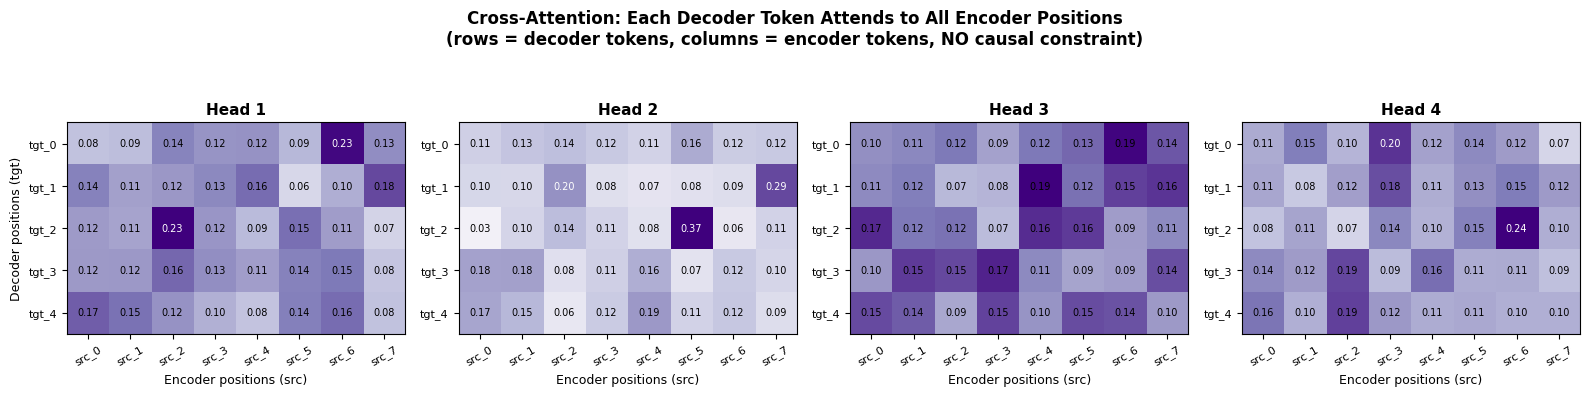

In [12]:
fig, axes = plt.subplots(1, num_heads, figsize=(16, 4))

src_labels = [f"src_{i}" for i in range(src_len)]
tgt_labels = [f"tgt_{i}" for i in range(tgt_len)]

for head_idx in range(num_heads):
    ax = axes[head_idx]
    # attn_weights: (batch, heads, tgt_len, src_len)
    weights = attn_weights[0, head_idx].detach().numpy()

    im = ax.imshow(weights, cmap="Purples", vmin=0, vmax=weights.max())
    ax.set_title(f"Head {head_idx + 1}", fontsize=11, fontweight="bold")

    ax.set_xticks(range(src_len))
    ax.set_yticks(range(tgt_len))
    ax.set_xticklabels(src_labels, fontsize=8, rotation=30)
    ax.set_yticklabels(tgt_labels, fontsize=8)

    for i in range(tgt_len):
        for j in range(src_len):
            val = weights[i, j]
            color = "white" if val > 0.2 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=color)

    if head_idx == 0:
        ax.set_ylabel("Decoder positions (tgt)", fontsize=9)
    ax.set_xlabel("Encoder positions (src)", fontsize=9)

plt.suptitle("Cross-Attention: Each Decoder Token Attends to All Encoder Positions\n"
             "(rows = decoder tokens, columns = encoder tokens, NO causal constraint)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

- The cross-attention matrix is **rectangular** — rows are decoder positions, columns are encoder positions
- Unlike masked self-attention, there is **no triangular constraint** — any decoder token can attend to any encoder token
- In practice, a decoder token for "dog" (in translation) would attend heavily to the corresponding word in the source
- Each head learns to focus on **different aspects** of the source sequence

---

## 4. Position-wise Feed-Forward Network (FFN)

- The FFN is **identical** to the one in the encoder
- It is applied independently at each position (no interaction between positions here)
- It consists of two linear transformations with a ReLU activation:
  $$\text{FFN}(x) = \text{ReLU}(xW_1 + b_1)W_2 + b_2$$
- The inner dimension `d_ff` is typically 4× the model dimension (e.g., 2048 when d_model=512)
- This expand-compress pattern gives the model extra capacity to learn complex transformations

In [13]:
class FeedForward(nn.Module):
    """Position-wise Feed-Forward Network (identical to encoder's FFN)."""

    def __init__(self, d_model, d_ff, dropout=0.0):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)   # expand
        self.linear2 = nn.Linear(d_ff, d_model)   # compress back
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        x = self.linear1(x)   # (batch, seq_len, d_ff)
        x = self.relu(x)      # activation
        x = self.dropout(x)
        x = self.linear2(x)   # (batch, seq_len, d_model)
        return x

In [14]:
# Demonstrate the expand-compress pattern
d_model, d_ff = 64, 256  # 4x expansion
ffn = FeedForward(d_model, d_ff)

x_in = torch.randn(2, 6, d_model)
x_out = ffn(x_in)

print(f"FFN input:  {x_in.shape}   -> Linear({d_model}, {d_ff}) -> ReLU -> Linear({d_ff}, {d_model})")
print(f"FFN output: {x_out.shape}  (same shape as input)")
print(f"Parameters: {sum(p.numel() for p in ffn.parameters()):,}")

FFN input:  torch.Size([2, 6, 64])   -> Linear(64, 256) -> ReLU -> Linear(256, 64)
FFN output: torch.Size([2, 6, 64])  (same shape as input)
Parameters: 33,088


---

## 5. Residual Connections (Recap)

- Just like in the encoder, each sub-layer in the decoder is wrapped with a **residual (skip) connection** and **layer normalization**:
  $$x = \text{LayerNorm}(x + \text{Sublayer}(x))$$
- The decoder has **three** such residual connections per block (one per sub-layer)
- Benefits:
  - **Gradient flow**: gradients can bypass layers without vanishing
  - **Identity shortcut**: if a sub-layer produces unhelpful output, the residual path preserves information
  - **Stable training**: prevents very deep networks from degrading

In [15]:
# Quick residual connection demo
torch.manual_seed(42)

x = torch.randn(1, 4, 8)

# Simulate a sub-layer (small random transformation)
sublayer = nn.Linear(8, 8)
sublayer_output = sublayer(x)

# Residual: add input to sub-layer output
residual_output = x + sublayer_output

# Apply layer norm
norm = nn.LayerNorm(8)
normed = norm(residual_output)

print(f"Input:              {x.shape},   mean={x.mean():.3f}, std={x.std():.3f}")
print(f"Sub-layer output:   {sublayer_output.shape},   mean={sublayer_output.mean():.3f}, std={sublayer_output.std():.3f}")
print(f"After residual:     {residual_output.shape},  mean={residual_output.mean():.3f}, std={residual_output.std():.3f}")
print(f"After layer norm:   {normed.shape},  mean={normed.mean():.3f}, std={normed.std():.3f}")

Input:              torch.Size([1, 4, 8]),   mean=0.218, std=1.083
Sub-layer output:   torch.Size([1, 4, 8]),   mean=-0.072, std=0.699
After residual:     torch.Size([1, 4, 8]),  mean=0.146, std=1.226
After layer norm:   torch.Size([1, 4, 8]),  mean=0.000, std=1.016


---

## 6. Putting It Together: The Decoder Block

- Now we combine all three sub-layers into a single **Decoder Block**
- The data flow inside each block:

```
Decoder Input (x)
       │
       ▼
┌─────────────────────────────┐
│  Masked Multi-Head           │
│  Self-Attention              │◄── Q, K, V all from x
└─────────────┬───────────────┘
              │
              ▼
        Add & Layer Norm  ◄── residual: x + dropout(attn_output)
              │
              ▼
┌─────────────────────────────┐
│  Cross-Attention             │◄── Q from decoder, K/V from encoder_output
└─────────────┬───────────────┘
              │
              ▼
        Add & Layer Norm  ◄── residual: x + dropout(cross_attn_output)
              │
              ▼
┌─────────────────────────────┐
│  Feed-Forward Network        │
└─────────────┬───────────────┘
              │
              ▼
        Add & Layer Norm  ◄── residual: x + dropout(ffn_output)
              │
              ▼
Decoder Block Output
```

In [16]:
class DecoderBlock(nn.Module):
    """A single Transformer Decoder Block with three sub-layers:
    1. Masked Multi-Head Self-Attention
    2. Cross-Attention (Encoder-Decoder Attention)
    3. Position-wise Feed-Forward Network
    """

    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        # Sub-layer 1: Masked Self-Attention
        self.self_attn  = MaskedMultiHeadSelfAttention(d_model, num_heads, dropout)
        self.norm1      = nn.LayerNorm(d_model)
        self.dropout1   = nn.Dropout(dropout)

        # Sub-layer 2: Cross-Attention
        self.cross_attn = CrossAttention(d_model, num_heads, dropout)
        self.norm2      = nn.LayerNorm(d_model)
        self.dropout2   = nn.Dropout(dropout)

        # Sub-layer 3: Feed-Forward Network
        self.ffn        = FeedForward(d_model, d_ff, dropout)
        self.norm3      = nn.LayerNorm(d_model)
        self.dropout3   = nn.Dropout(dropout)

    def forward(self, x, encoder_output):
        # x:              (batch, tgt_len, d_model)
        # encoder_output: (batch, src_len, d_model)

        # Sub-layer 1: Masked Self-Attention + Residual + Norm
        self_attn_out, self_attn_weights = self.self_attn(x)
        x = self.norm1(x + self.dropout1(self_attn_out))

        # Sub-layer 2: Cross-Attention + Residual + Norm
        cross_attn_out, cross_attn_weights = self.cross_attn(x, encoder_output)
        x = self.norm2(x + self.dropout2(cross_attn_out))

        # Sub-layer 3: FFN + Residual + Norm
        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout3(ffn_out))

        return x, self_attn_weights, cross_attn_weights

In [17]:
# Test the decoder block
torch.manual_seed(123)

d_model  = 64
num_heads = 4
d_ff     = 256
src_len  = 8   # encoder sequence length
tgt_len  = 5   # decoder sequence length
batch_size = 2

decoder_block = DecoderBlock(d_model, num_heads, d_ff, dropout=0.0)

x            = torch.randn(batch_size, tgt_len, d_model)
encoder_out  = torch.randn(batch_size, src_len, d_model)

output, self_w, cross_w = decoder_block(x, encoder_out)

print(f"Input (decoder state): {x.shape}")
print(f"Encoder output:        {encoder_out.shape}")
print(f"Decoder block output:  {output.shape}")
print(f"Self-attn weights:     {self_w.shape}   (batch, heads, tgt, tgt)")
print(f"Cross-attn weights:    {cross_w.shape}   (batch, heads, tgt, src)")
print(f"\nTotal parameters: {sum(p.numel() for p in decoder_block.parameters()):,}")

Input (decoder state): torch.Size([2, 5, 64])
Encoder output:        torch.Size([2, 8, 64])
Decoder block output:  torch.Size([2, 5, 64])
Self-attn weights:     torch.Size([2, 4, 5, 5])   (batch, heads, tgt, tgt)
Cross-attn weights:    torch.Size([2, 4, 5, 8])   (batch, heads, tgt, src)

Total parameters: 66,752


### 6.1 Visualizing Data Flow Through the Decoder Block

Input                      mean=-0.096  std=0.973  min=-3.008  max=3.058
After Masked Self-Attn     mean=0.000  std=1.000  min=-3.185  max=3.417
After Cross Attention      mean=0.000  std=1.000  min=-3.143  max=3.557
After FFN (Output)         mean=0.000  std=1.000  min=-3.022  max=3.399


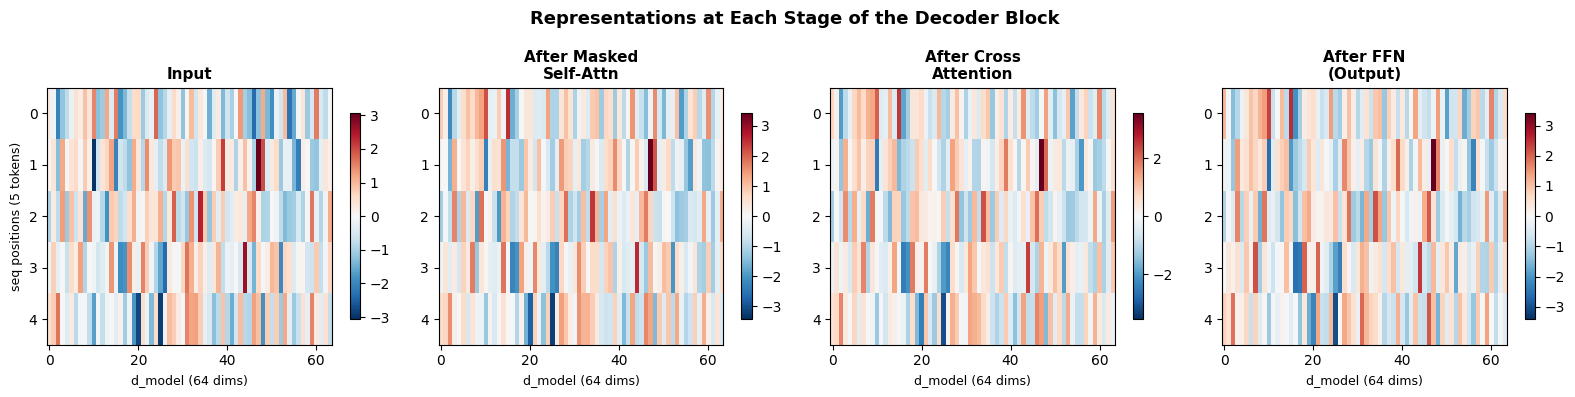

In [18]:
# Trace the data flow step by step
torch.manual_seed(123)
block = DecoderBlock(d_model, num_heads, d_ff, dropout=0.0)
block.eval()

x_in = torch.randn(1, tgt_len, d_model)
enc  = torch.randn(1, src_len, d_model)

with torch.no_grad():
    # Step 1: Masked self-attention
    sa_out, sa_w = block.self_attn(x_in)
    after_sa     = block.norm1(x_in + sa_out)

    # Step 2: Cross-attention
    ca_out, ca_w = block.cross_attn(after_sa, enc)
    after_ca     = block.norm2(after_sa + ca_out)

    # Step 3: FFN
    ffn_out  = block.ffn(after_ca)
    after_ffn = block.norm3(after_ca + ffn_out)

stages = {
    "Input": x_in[0].detach().numpy(),
    "After Masked\nSelf-Attn": after_sa[0].detach().numpy(),
    "After Cross\nAttention": after_ca[0].detach().numpy(),
    "After FFN\n(Output)": after_ffn[0].detach().numpy(),
}

fig, axes = plt.subplots(1, len(stages), figsize=(16, 4))

for idx, (name, data) in enumerate(stages.items()):
    vmax = max(abs(data.min()), abs(data.max()))
    im = axes[idx].imshow(data, cmap="RdBu_r", aspect="auto", vmin=-vmax, vmax=vmax)
    axes[idx].set_title(name, fontsize=11, fontweight="bold")
    axes[idx].set_xlabel(f"d_model ({d_model} dims)", fontsize=9)
    if idx == 0:
        axes[idx].set_ylabel(f"seq positions ({tgt_len} tokens)", fontsize=9)
    plt.colorbar(im, ax=axes[idx], shrink=0.8)

    # Print stats
    print(f"{name.replace(chr(10), " "):25s}  mean={data.mean():.3f}  std={data.std():.3f}  "
          f"min={data.min():.3f}  max={data.max():.3f}")

plt.suptitle("Representations at Each Stage of the Decoder Block",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

- Each sub-layer **refines** the representation while maintaining the same shape `(tgt_len, d_model)`
- Layer norm keeps the values **well-scaled** at each stage (mean ≈ 0, std ≈ 1)
- The residual connection ensures the original input information is preserved through each transformation

---

## 7. The Full Transformer Decoder

- The full decoder stacks **N identical Decoder Blocks**
- On top of the stacked blocks, a **linear projection** maps each token's representation to vocabulary logits
- A **softmax** turns those logits into a probability distribution over the vocabulary
- The original Transformer uses N=6 blocks; modern models use many more (GPT-3: 96 layers)
- During training, **all target positions are computed in parallel** (teacher forcing)
- During inference, tokens are generated **one at a time**, left-to-right

In [19]:
class TransformerDecoder(nn.Module):
    """Full Transformer Decoder:
    Target Embedding + Positional Encoding + N Decoder Blocks + Linear output head.
    """

    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers,
                 max_len=512, dropout=0.1):
        super().__init__()

        # Input processing (target sequence)
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding    = SinusoidalPositionalEncoding(d_model, max_len)
        self.dropout         = nn.Dropout(dropout)

        # Stack of N decoder blocks
        self.layers = nn.ModuleList([
            DecoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        # Final layer norm
        self.norm = nn.LayerNorm(d_model)

        # Output head: project to vocabulary logits
        self.output_projection = nn.Linear(d_model, vocab_size)

        self.d_model = d_model

    def forward(self, tgt_ids, encoder_output):
        # tgt_ids:        (batch, tgt_len)       — target token IDs
        # encoder_output: (batch, src_len, d_model) — encoder memory

        # Step 1: Target embedding (scaled) + positional encoding
        x = self.token_embedding(tgt_ids) * (self.d_model ** 0.5)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        # Step 2: Pass through N decoder blocks
        all_self_attn_weights  = []
        all_cross_attn_weights = []
        for layer in self.layers:
            x, self_w, cross_w = layer(x, encoder_output)
            all_self_attn_weights.append(self_w)
            all_cross_attn_weights.append(cross_w)

        # Step 3: Final layer norm
        x = self.norm(x)

        # Step 4: Project to vocabulary logits
        logits = self.output_projection(x)  # (batch, tgt_len, vocab_size)

        return logits, all_self_attn_weights, all_cross_attn_weights

In [20]:
# Create a Transformer Decoder (scaled-down configuration)
torch.manual_seed(123)

VOCAB_SIZE  = 1000
D_MODEL     = 64
NUM_HEADS   = 4
D_FF        = 256
NUM_LAYERS  = 4
MAX_LEN     = 128
DROPOUT     = 0.1

decoder = TransformerDecoder(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    num_layers=NUM_LAYERS,
    max_len=MAX_LEN,
    dropout=DROPOUT
)

total_params     = sum(p.numel() for p in decoder.parameters())
trainable_params = sum(p.numel() for p in decoder.parameters() if p.requires_grad)

print(f"Transformer Decoder created!")
print(f"  Layers:              {NUM_LAYERS}")
print(f"  d_model:             {D_MODEL}")
print(f"  Heads:               {NUM_HEADS}")
print(f"  d_ff:                {D_FF}")
print(f"  Total parameters:    {total_params:,}")
print(f"  Trainable params:    {trainable_params:,}")

Transformer Decoder created!
  Layers:              4
  d_model:             64
  Heads:               4
  d_ff:                256
  Total parameters:    396,136
  Trainable params:    396,136


In [21]:
# Forward pass: simulate an encoder output + target tokens
decoder.eval()

SRC_LEN = 8   # source sequence length (from encoder)
TGT_LEN = 5   # target sequence length
BATCH   = 2

# Simulated encoder output (in practice this comes from a real encoder)
encoder_output = torch.randn(BATCH, SRC_LEN, D_MODEL)

# Target token IDs (shifted-right during training; partial sequence during inference)
tgt_ids = torch.tensor([
    [1, 42, 100, 7, 256],   # <BOS>, tok1, tok2, tok3, tok4
    [1, 33,  78, 90, 11],
])

with torch.no_grad():
    logits, self_attn_ws, cross_attn_ws = decoder(tgt_ids, encoder_output)

print(f"Target IDs shape:      {tgt_ids.shape}          (batch, tgt_len)")
print(f"Encoder output shape:  {encoder_output.shape}  (batch, src_len, d_model)")
print(f"Logits shape:          {logits.shape}  (batch, tgt_len, vocab_size)")
print(f"\nSelf-attention weights:  {len(self_attn_ws)} layers, each {self_attn_ws[0].shape}")
print(f"Cross-attention weights: {len(cross_attn_ws)} layers, each {cross_attn_ws[0].shape}")

# The logit at position i predicts the token at position i+1
probs = torch.softmax(logits[0, -1], dim=-1)  # last position of first batch
top5  = probs.topk(5)
print(f"\nTop-5 predicted next tokens (from last decoder position):")
for token_id, prob in zip(top5.indices.tolist(), top5.values.tolist()):
    print(f"  Token {token_id:4d}: {prob:.4f}")

Target IDs shape:      torch.Size([2, 5])          (batch, tgt_len)
Encoder output shape:  torch.Size([2, 8, 64])  (batch, src_len, d_model)
Logits shape:          torch.Size([2, 5, 1000])  (batch, tgt_len, vocab_size)

Self-attention weights:  4 layers, each torch.Size([2, 4, 5, 5])
Cross-attention weights: 4 layers, each torch.Size([2, 4, 5, 8])

Top-5 predicted next tokens (from last decoder position):
  Token  578: 0.0073
  Token  761: 0.0038
  Token  232: 0.0037
  Token  796: 0.0035
  Token  412: 0.0033


### 7.1 Visualizing Attention Across All Layers

- Let's visualize both **self-attention** (causal, decoder-to-decoder) and **cross-attention** (decoder-to-encoder) patterns across all layers
- Self-attention should always show the lower-triangular causal pattern
- Cross-attention patterns reveal which encoder positions each decoder position focuses on

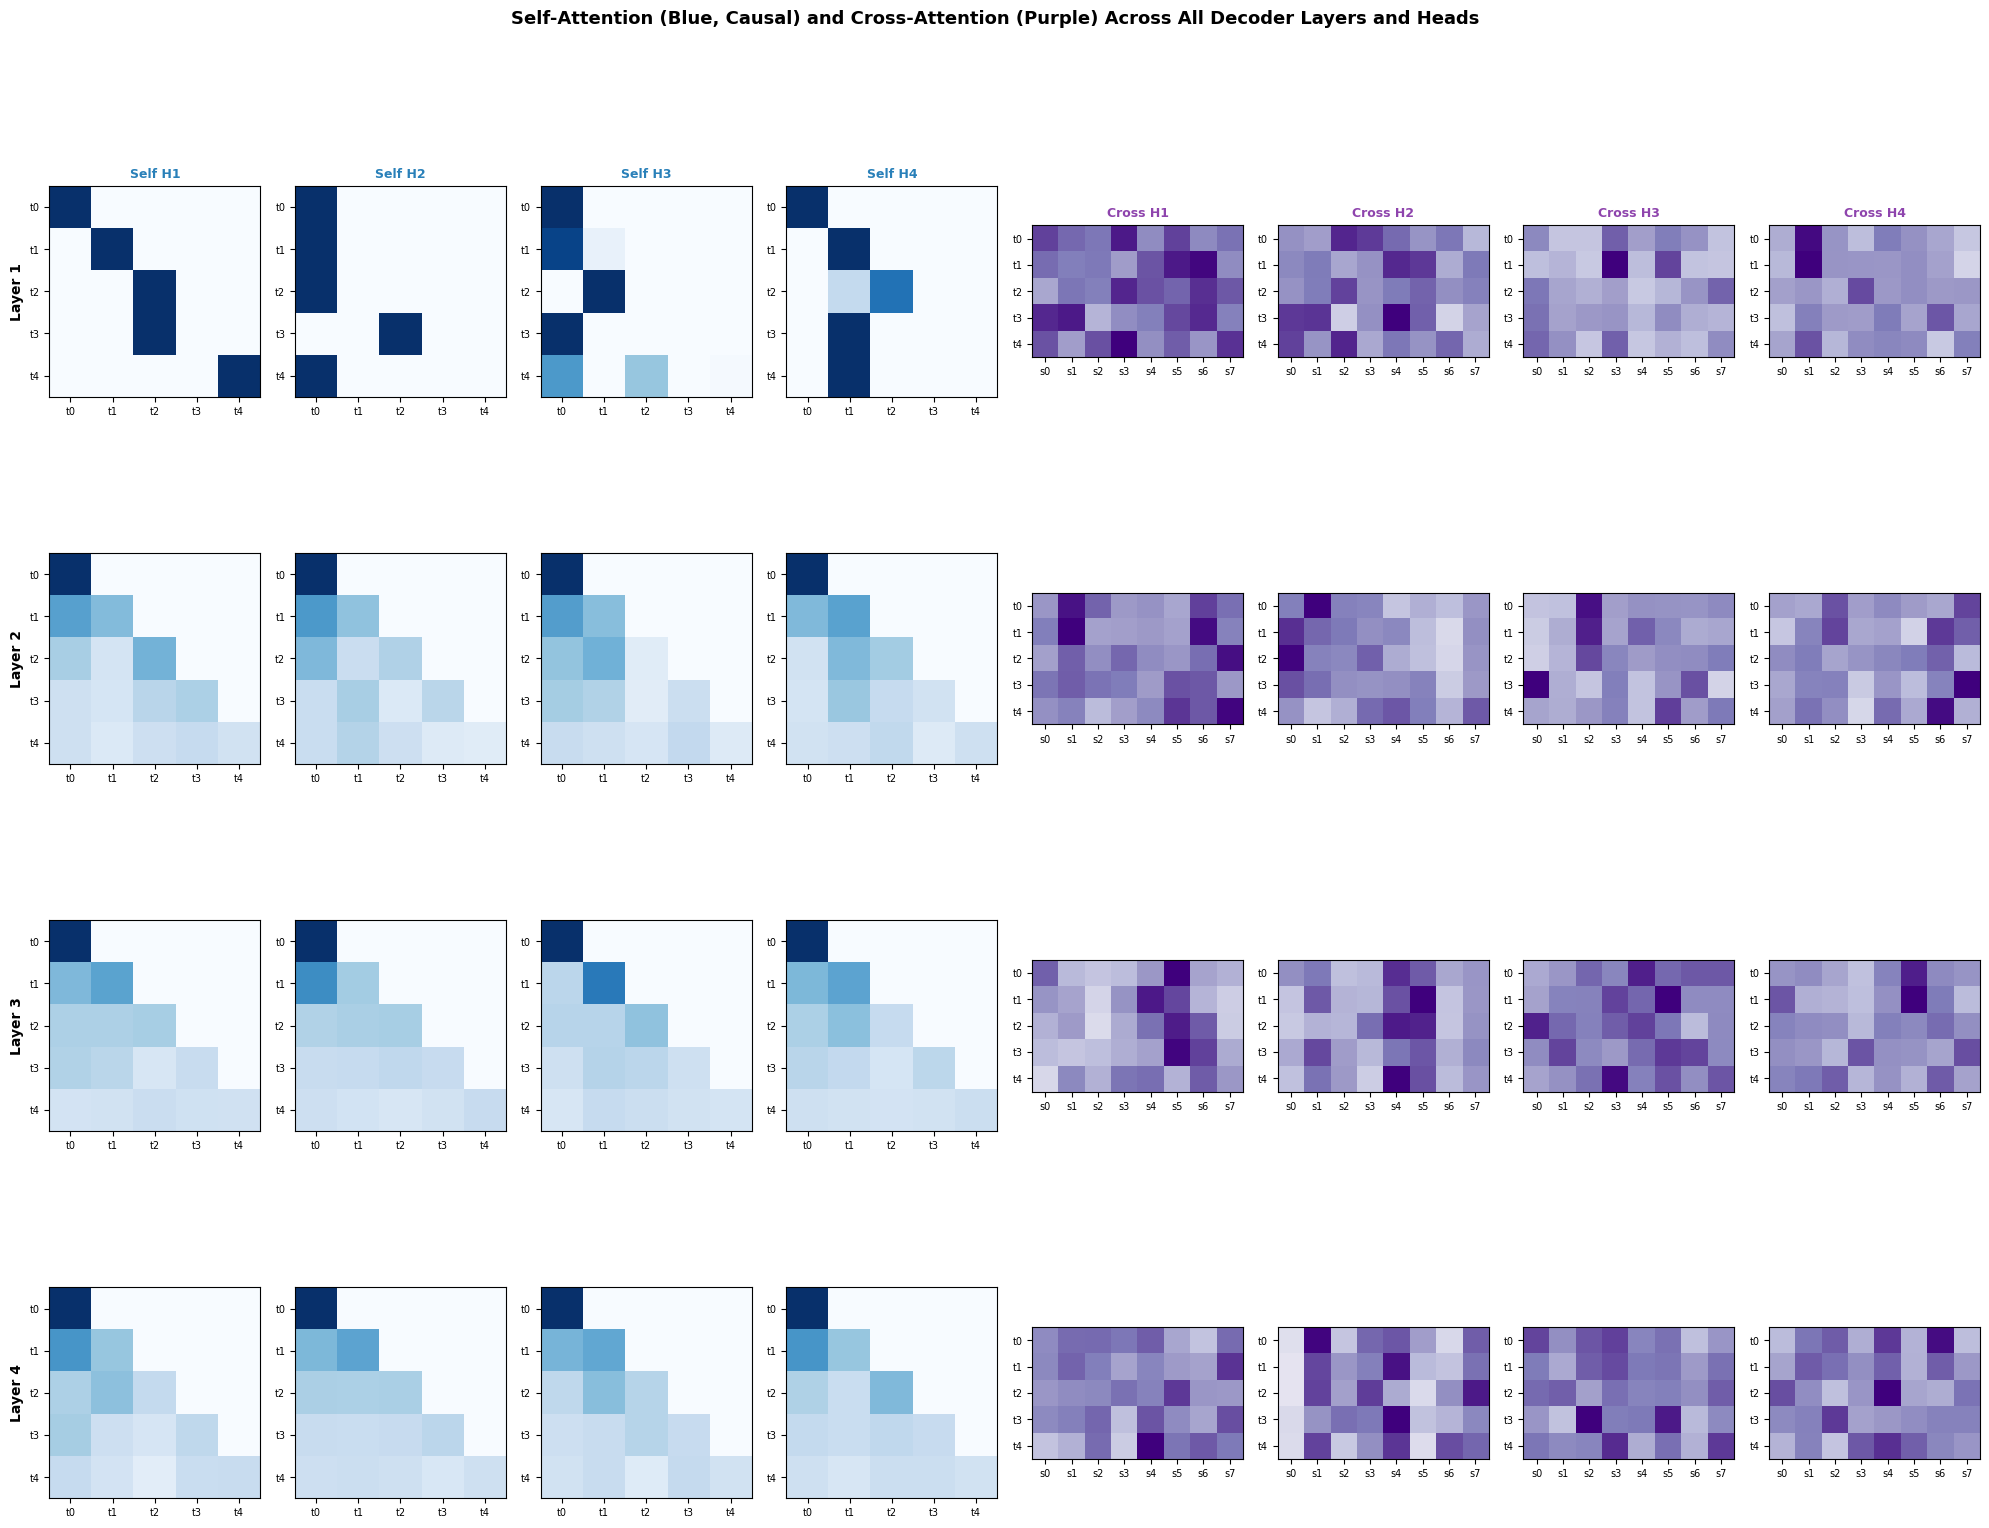

In [22]:
fig, axes = plt.subplots(NUM_LAYERS, 2 * NUM_HEADS, figsize=(20, 4 * NUM_LAYERS))

src_labels = [f"s{i}" for i in range(SRC_LEN)]
tgt_labels = [f"t{i}" for i in range(TGT_LEN)]

for layer_idx in range(NUM_LAYERS):
    for head_idx in range(NUM_HEADS):
        # ── Self-attention (left half) ────────────────────────────────────
        ax_self = axes[layer_idx, head_idx]
        sw = self_attn_ws[layer_idx][0, head_idx].detach().numpy()  # (tgt, tgt)
        ax_self.imshow(sw, cmap="Blues", vmin=0, vmax=sw.max())

        if layer_idx == 0:
            ax_self.set_title(f"Self H{head_idx+1}", fontsize=9, fontweight="bold", color="#2980b9")
        if head_idx == 0:
            ax_self.set_ylabel(f"Layer {layer_idx+1}", fontsize=10, fontweight="bold")

        ax_self.set_xticks(range(TGT_LEN))
        ax_self.set_yticks(range(TGT_LEN))
        ax_self.set_xticklabels(tgt_labels, fontsize=7)
        ax_self.set_yticklabels(tgt_labels, fontsize=7)

        # ── Cross-attention (right half) ──────────────────────────────────
        ax_cross = axes[layer_idx, NUM_HEADS + head_idx]
        cw = cross_attn_ws[layer_idx][0, head_idx].detach().numpy()  # (tgt, src)
        ax_cross.imshow(cw, cmap="Purples", vmin=0, vmax=cw.max())

        if layer_idx == 0:
            ax_cross.set_title(f"Cross H{head_idx+1}", fontsize=9, fontweight="bold", color="#8e44ad")

        ax_cross.set_xticks(range(SRC_LEN))
        ax_cross.set_yticks(range(TGT_LEN))
        ax_cross.set_xticklabels(src_labels, fontsize=7)
        ax_cross.set_yticklabels(tgt_labels, fontsize=7)

plt.suptitle("Self-Attention (Blue, Causal) and Cross-Attention (Purple) Across All Decoder Layers and Heads",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

- **Blue (self-attention)**: always shows the lower-triangular causal pattern — no future positions
- **Purple (cross-attention)**: rectangular matrix (tgt × src) — no masking constraints
- Earlier layers tend to have more **local** attention patterns; later layers capture more **global** relationships
- Each head specializes in a different aspect of the source-target alignment

### 7.2 Parameter Distribution

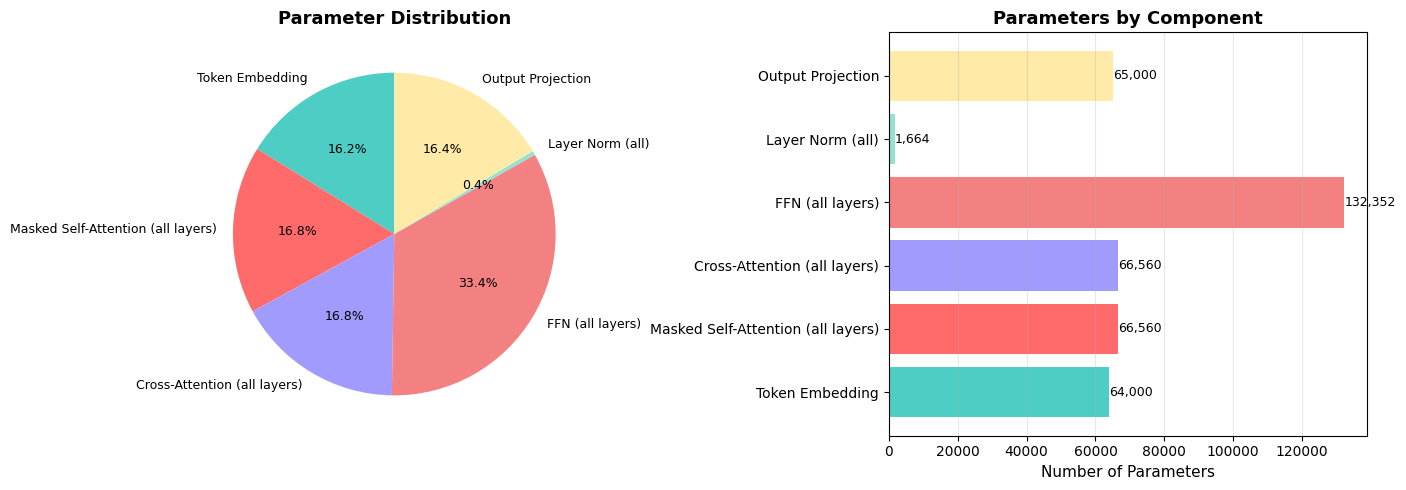


Parameter breakdown:
  Token Embedding                         :   64,000  (16.2%)
  Masked Self-Attention (all layers)      :   66,560  (16.8%)
  Cross-Attention (all layers)            :   66,560  (16.8%)
  FFN (all layers)                        :  132,352  (33.4%)
  Layer Norm (all)                        :    1,664  (0.4%)
  Output Projection                       :   65,000  (16.4%)
  Total                                   :  396,136


In [23]:
# Count parameters by component
param_counts = {}
param_counts["Token Embedding"] = sum(p.numel() for p in decoder.token_embedding.parameters())

self_attn_params  = 0
cross_attn_params = 0
ffn_params        = 0
norm_params       = 0

for layer in decoder.layers:
    self_attn_params  += sum(p.numel() for p in layer.self_attn.parameters())
    cross_attn_params += sum(p.numel() for p in layer.cross_attn.parameters())
    ffn_params        += sum(p.numel() for p in layer.ffn.parameters())
    norm_params       += sum(p.numel() for p in layer.norm1.parameters())
    norm_params       += sum(p.numel() for p in layer.norm2.parameters())
    norm_params       += sum(p.numel() for p in layer.norm3.parameters())

norm_params += sum(p.numel() for p in decoder.norm.parameters())
param_counts["Masked Self-Attention (all layers)"] = self_attn_params
param_counts["Cross-Attention (all layers)"]       = cross_attn_params
param_counts["FFN (all layers)"]                   = ffn_params
param_counts["Layer Norm (all)"]                   = norm_params
param_counts["Output Projection"]                  = sum(p.numel() for p in decoder.output_projection.parameters())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_pie = ["#4ECDC4", "#FF6B6B", "#A29BFE", "#F38181", "#95E1D3", "#FFEAA7"]
labels = list(param_counts.keys())
sizes  = list(param_counts.values())

axes[0].pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors_pie,
            startangle=90, textprops={"fontsize": 9})
axes[0].set_title("Parameter Distribution", fontsize=13, fontweight="bold")

bars = axes[1].barh(labels, sizes, color=colors_pie)
axes[1].set_xlabel("Number of Parameters", fontsize=11)
axes[1].set_title("Parameters by Component", fontsize=13, fontweight="bold")
for bar, size in zip(bars, sizes):
    axes[1].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                f"{size:,}", va="center", fontsize=9)
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nParameter breakdown:")
for name, count in param_counts.items():
    pct = 100 * count / sum(sizes)
    print(f"  {name:<40s}: {count:>8,}  ({pct:.1f}%)")
print(f"  {'Total':<40s}: {sum(sizes):>8,}")

- The decoder has **twice the attention parameters** of the encoder (self-attn + cross-attn)
- The **FFN** still dominates due to the 4x expansion
- The **output projection** connects d_model to the full vocabulary — it can be large for big vocabularies
- In practice, the output projection weights are often **tied** to the input embedding weights to save parameters

---

## 8. Autoregressive Generation

- During **training**, the decoder processes the full target sequence at once (teacher forcing)
  - Input: `[<BOS>, tok1, tok2, tok3]`
  - Target: `[tok1, tok2, tok3, <EOS>]`
  - The causal mask ensures position `i` only sees positions `0..i` — simulating inference
- During **inference**, the decoder generates tokens **one at a time**:
  1. Start with `[<BOS>]`
  2. Run forward pass → get logits for next token
  3. Sample or argmax to pick the next token
  4. Append it to the sequence, repeat until `<EOS>` or max length
- This is called **autoregressive** generation — each token depends on all previous tokens

### 8.1 Greedy Decoding Step by Step

In [24]:
def greedy_decode(decoder_model, encoder_output, bos_token_id, eos_token_id, max_new_tokens=20):
    """Generate tokens autoregressively using greedy decoding (always pick argmax).
    
    Args:
        decoder_model:   a TransformerDecoder
        encoder_output:  (1, src_len, d_model) — from the encoder
        bos_token_id:    beginning-of-sequence token ID
        eos_token_id:    end-of-sequence token ID
        max_new_tokens:  maximum number of tokens to generate
    Returns:
        list of generated token IDs (including BOS, excluding EOS)
    """
    decoder_model.eval()

    generated = [bos_token_id]  # start with BOS

    with torch.no_grad():
        for step in range(max_new_tokens):
            # Current token sequence as a tensor
            tgt = torch.tensor([generated])  # (1, current_len)

            # Forward pass through the decoder
            logits, _, _ = decoder_model(tgt, encoder_output)

            # Take the logits at the LAST position (next-token prediction)
            next_token_logits = logits[0, -1, :]  # (vocab_size,)

            # Greedy: pick the highest-probability token
            next_token = next_token_logits.argmax().item()

            generated.append(next_token)

            # Stop if we generated the EOS token
            if next_token == eos_token_id:
                break

    return generated

In [25]:
# Run step-by-step greedy decoding
torch.manual_seed(42)

BOS_ID = 1
EOS_ID = 2

# Small decoder for clear visualization
small_decoder = TransformerDecoder(
    vocab_size=50, d_model=32, num_heads=4, d_ff=128,
    num_layers=2, max_len=32, dropout=0.0
)

# Simulated encoder output
enc_out = torch.randn(1, 6, 32)

print("=" * 55)
print("AUTOREGRESSIVE GENERATION: STEP BY STEP")
print("=" * 55)

small_decoder.eval()
generated = [BOS_ID]

with torch.no_grad():
    for step in range(10):
        tgt = torch.tensor([generated])
        logits, _, _ = small_decoder(tgt, enc_out)

        next_logits = logits[0, -1, :]        # (vocab_size,)
        probs       = torch.softmax(next_logits, dim=-1)
        next_token  = next_logits.argmax().item()
        top3        = probs.topk(3)

        print(f"\nStep {step+1}: input = {generated}")
        print(f"  Top-3 candidates: ", end="")
        for tok, prob in zip(top3.indices.tolist(), top3.values.tolist()):
            marker = " <-- CHOSEN" if tok == next_token else ""
            print(f"tok_{tok}({prob:.3f}){marker}", end="  ")
        print()

        generated.append(next_token)

        if next_token == EOS_ID:
            print(f"\n<EOS> generated — stopping.")
            break

print(f"\nFinal generated sequence: {generated}")

AUTOREGRESSIVE GENERATION: STEP BY STEP

Step 1: input = [1]
  Top-3 candidates: tok_29(0.058) <-- CHOSEN  tok_49(0.049)  tok_44(0.049)  

Step 2: input = [1, 29]
  Top-3 candidates: tok_21(0.058) <-- CHOSEN  tok_37(0.055)  tok_35(0.052)  

Step 3: input = [1, 29, 21]
  Top-3 candidates: tok_47(0.065) <-- CHOSEN  tok_29(0.061)  tok_37(0.050)  

Step 4: input = [1, 29, 21, 47]
  Top-3 candidates: tok_32(0.074) <-- CHOSEN  tok_29(0.050)  tok_35(0.042)  

Step 5: input = [1, 29, 21, 47, 32]
  Top-3 candidates: tok_21(0.070) <-- CHOSEN  tok_38(0.059)  tok_44(0.054)  

Step 6: input = [1, 29, 21, 47, 32, 21]
  Top-3 candidates: tok_47(0.069) <-- CHOSEN  tok_37(0.060)  tok_29(0.059)  

Step 7: input = [1, 29, 21, 47, 32, 21, 47]
  Top-3 candidates: tok_32(0.070) <-- CHOSEN  tok_29(0.048)  tok_45(0.042)  

Step 8: input = [1, 29, 21, 47, 32, 21, 47, 32]
  Top-3 candidates: tok_21(0.064) <-- CHOSEN  tok_38(0.061)  tok_44(0.053)  

Step 9: input = [1, 29, 21, 47, 32, 21, 47, 32, 21]
  Top-3 can

- At each step, the **entire prefix** is re-processed by the decoder
- The causal mask ensures the model only sees tokens up to the current position
- Greedy decoding always picks the single most likely next token — fast but not always optimal
- Alternatives include **beam search** (keep top-k sequences), **top-p/top-k sampling** (stochastic), and **temperature scaling**

### 8.2 Visualizing the Generation Process

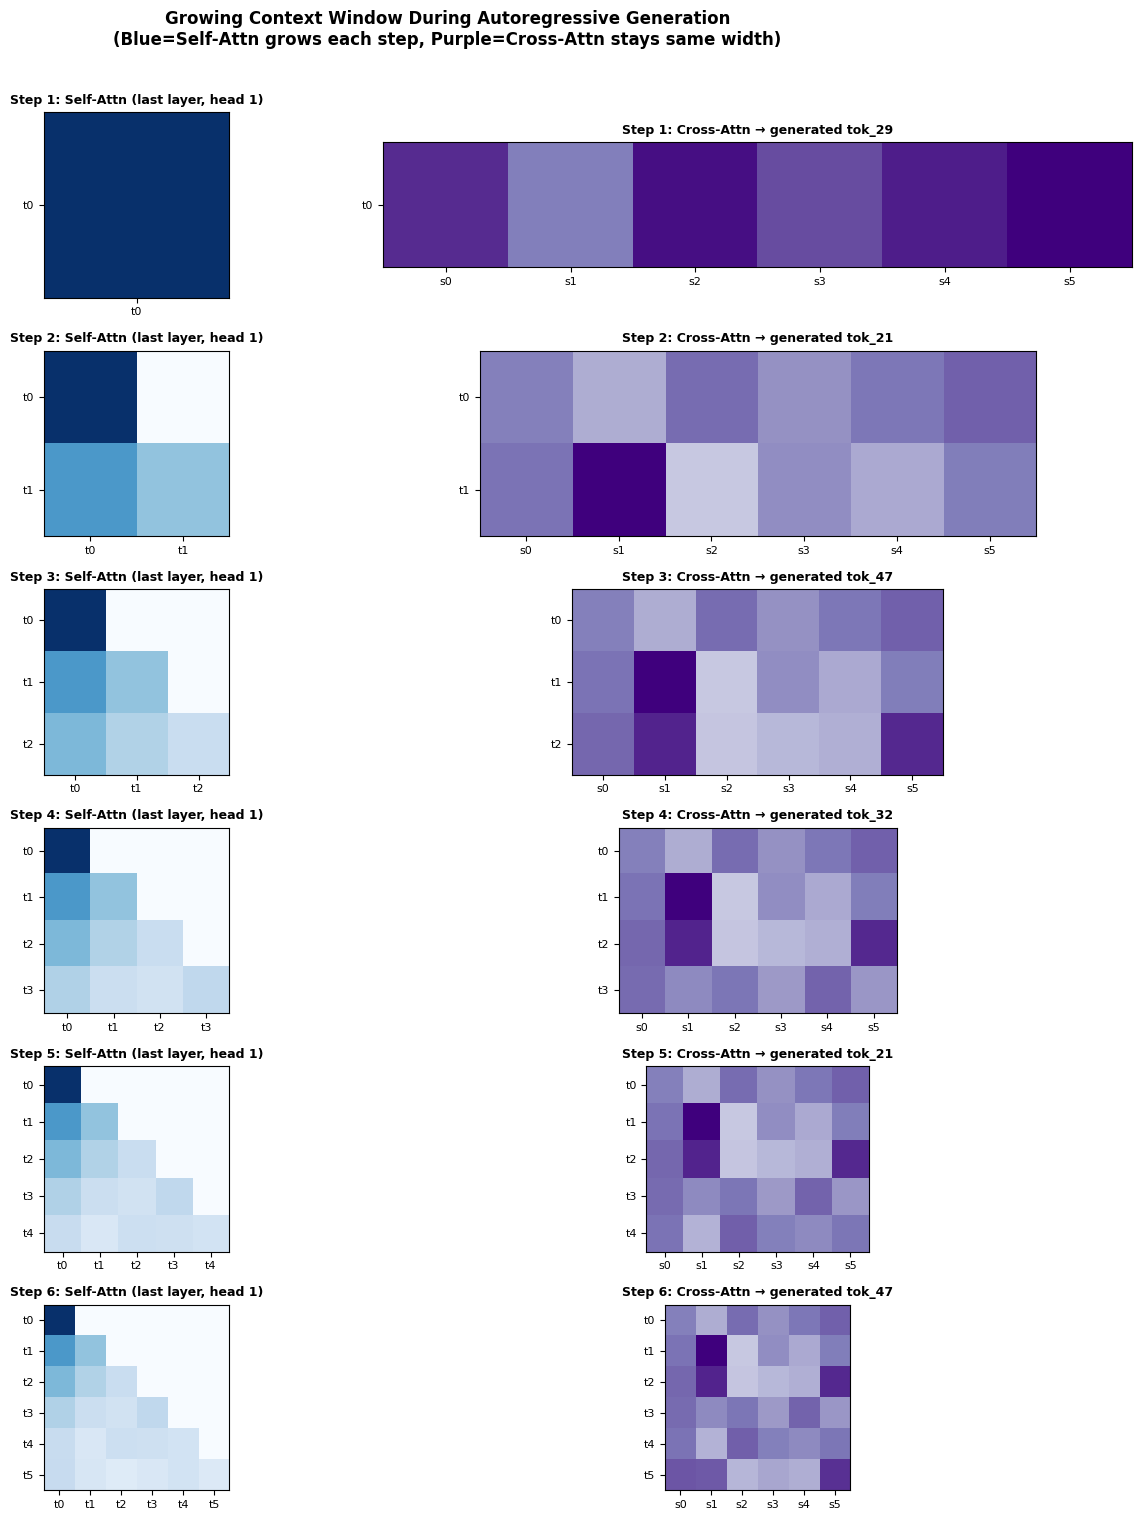

In [26]:
# Visualize how the context window grows at each generation step
torch.manual_seed(42)

small_decoder2 = TransformerDecoder(
    vocab_size=50, d_model=32, num_heads=4, d_ff=128,
    num_layers=2, max_len=32, dropout=0.0
)
small_decoder2.eval()
enc_out2 = torch.randn(1, 6, 32)

num_steps = 6
fig, axes = plt.subplots(num_steps, 2, figsize=(14, num_steps * 2.5))

gen = [BOS_ID]

with torch.no_grad():
    for step in range(num_steps):
        tgt = torch.tensor([gen])
        logits, self_ws, cross_ws = small_decoder2(tgt, enc_out2)

        next_token = logits[0, -1].argmax().item()
        cur_len    = len(gen)

        # Self-attention weights (last layer, first head)
        sw = self_ws[-1][0, 0].detach().numpy()  # (cur_len, cur_len)
        axes[step, 0].imshow(sw, cmap="Blues", vmin=0, vmax=sw.max())
        axes[step, 0].set_title(f"Step {step+1}: Self-Attn (last layer, head 1)",
                                fontsize=9, fontweight="bold")
        axes[step, 0].set_xticks(range(cur_len))
        axes[step, 0].set_yticks(range(cur_len))
        axes[step, 0].set_xticklabels([f"t{i}" for i in range(cur_len)], fontsize=8)
        axes[step, 0].set_yticklabels([f"t{i}" for i in range(cur_len)], fontsize=8)

        # Cross-attention weights (last layer, first head): (cur_len, src_len)
        cw = cross_ws[-1][0, 0].detach().numpy()
        axes[step, 1].imshow(cw, cmap="Purples", vmin=0, vmax=cw.max())
        axes[step, 1].set_title(f"Step {step+1}: Cross-Attn → generated tok_{next_token}",
                                fontsize=9, fontweight="bold")
        axes[step, 1].set_xticks(range(6))
        axes[step, 1].set_yticks(range(cur_len))
        axes[step, 1].set_xticklabels([f"s{i}" for i in range(6)], fontsize=8)
        axes[step, 1].set_yticklabels([f"t{i}" for i in range(cur_len)], fontsize=8)

        gen.append(next_token)

plt.suptitle("Growing Context Window During Autoregressive Generation\n"
             "(Blue=Self-Attn grows each step, Purple=Cross-Attn stays same width)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

- **Self-attention** (blue) grows with each step — the attention matrix gets larger as the sequence grows
- **Cross-attention** (purple) always has the same number of columns (source length = fixed), but gains rows as we generate more tokens
- At each step, the **bottom-right** element of the self-attention matrix is what matters for the next-token prediction (the last query attending to all previous keys)
- The cross-attention at the last generated position tells us which encoder tokens influenced this generation step

---

## 9. Decoder-Only Architecture (GPT-style)

- Models like **GPT**, **LLaMA**, and **Mistral** use a **decoder-only** architecture
- There is **no encoder** and therefore **no cross-attention** — only masked self-attention + FFN
- The model learns to predict the next token given all previous tokens (language modeling)
- Despite the simpler architecture, decoder-only models have proven extremely powerful for generation tasks
- With sufficient data and scale, they can also handle tasks that seem to require understanding (classification, Q&A, etc.) via in-context learning

| Feature | Full Transformer Decoder | Decoder-Only (GPT-style) |
|---------|--------------------------|---------------------------|
| Self-Attention | Masked (causal) | Masked (causal) |
| Cross-Attention | Yes (from encoder) | **No** |
| Sub-layers per block | 3 | 2 |
| Encoder required | Yes | **No** |
| Use case | Translation, summarization | Language modeling, generation |

In [27]:
class GPTDecoderBlock(nn.Module):
    """Decoder-only block (GPT-style): no cross-attention.
    Two sub-layers: Masked Self-Attention + FFN.
    """

    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        # Sub-layer 1: Masked Self-Attention
        self.self_attn = MaskedMultiHeadSelfAttention(d_model, num_heads, dropout)
        self.norm1     = nn.LayerNorm(d_model)
        self.dropout1  = nn.Dropout(dropout)

        # Sub-layer 2: Feed-Forward Network
        self.ffn      = FeedForward(d_model, d_ff, dropout)
        self.norm2    = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq_len, d_model)

        # Sub-layer 1: Masked Self-Attention + Residual + Norm
        attn_out, attn_weights = self.self_attn(x)
        x = self.norm1(x + self.dropout1(attn_out))

        # Sub-layer 2: FFN + Residual + Norm
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))

        return x, attn_weights

In [28]:
class GPTDecoder(nn.Module):
    """Decoder-only Transformer (GPT-style).
    No encoder input — predicts next token from context alone.
    """

    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers,
                 max_len=512, dropout=0.1):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding    = SinusoidalPositionalEncoding(d_model, max_len)
        self.dropout         = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            GPTDecoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.norm              = nn.LayerNorm(d_model)
        self.output_projection = nn.Linear(d_model, vocab_size)
        self.d_model           = d_model

    def forward(self, token_ids):
        # token_ids: (batch, seq_len)

        x = self.token_embedding(token_ids) * (self.d_model ** 0.5)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        all_attn_weights = []
        for layer in self.layers:
            x, attn_w = layer(x)
            all_attn_weights.append(attn_w)

        x      = self.norm(x)
        logits = self.output_projection(x)  # (batch, seq_len, vocab_size)

        return logits, all_attn_weights

In [29]:
# Create and test a GPT-style decoder-only model
torch.manual_seed(123)

gpt = GPTDecoder(
    vocab_size=1000, d_model=64, num_heads=4, d_ff=256,
    num_layers=4, max_len=128, dropout=0.0
)
gpt.eval()

# Input: a sequence of token IDs
tokens = torch.tensor([[1, 42, 100, 7, 256, 88]])  # (batch=1, seq_len=6)

with torch.no_grad():
    logits, attn_ws = gpt(tokens)

print(f"Input shape:   {tokens.shape}    (batch=1, seq_len=6)")
print(f"Logits shape:  {logits.shape}  (batch=1, seq_len=6, vocab=1000)")
print(f"Attn weights:  {len(attn_ws)} layers, each {attn_ws[0].shape}")
print(f"\nTotal GPT parameters: {sum(p.numel() for p in gpt.parameters()):,}")

# Compare with the full decoder
full_dec_params = sum(p.numel() for p in decoder.parameters())
gpt_params      = sum(p.numel() for p in gpt.parameters())
print(f"Full Decoder params:  {full_dec_params:,}")
print(f"GPT Decoder params:   {gpt_params:,}")
print(f"Difference (cross-attn):  {full_dec_params - gpt_params:,}")

Input shape:   torch.Size([1, 6])    (batch=1, seq_len=6)
Logits shape:  torch.Size([1, 6, 1000])  (batch=1, seq_len=6, vocab=1000)
Attn weights:  4 layers, each torch.Size([1, 4, 6, 6])

Total GPT parameters: 329,064
Full Decoder params:  396,136
GPT Decoder params:   329,064
Difference (cross-attn):  67,072


In [30]:
# Autoregressive generation with GPT-style decoder
def gpt_generate(model, prompt_ids, max_new_tokens=10, temperature=1.0):
    """Greedy generation with a decoder-only model. No encoder needed."""
    model.eval()
    generated = list(prompt_ids)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            ids    = torch.tensor([generated])
            logits, _ = model(ids)
            next_logits = logits[0, -1] / temperature
            next_token  = next_logits.argmax().item()
            generated.append(next_token)
            if next_token == 2:  # EOS
                break
    return generated

torch.manual_seed(0)
gpt2 = GPTDecoder(vocab_size=50, d_model=32, num_heads=4, d_ff=128,
                  num_layers=2, max_len=32, dropout=0.0)

prompt = [1, 5, 12]  # <BOS>, tok5, tok12
result = gpt_generate(gpt2, prompt, max_new_tokens=8)

print(f"Prompt:    {prompt}")
print(f"Generated: {result}")
print(f"New tokens: {result[len(prompt):]}")

Prompt:    [1, 5, 12]
Generated: [1, 5, 12, 4, 11, 20, 4, 11, 20, 4, 11]
New tokens: [4, 11, 20, 4, 11, 20, 4, 11]


- The GPT-style model generates purely from its own previous tokens — **no encoder memory**
- This makes it simpler and more scalable: you only need one model instead of encoder+decoder
- Modern large language models (GPT-4, LLaMA, Claude) all use this decoder-only pattern
- Temperature controls randomness: `temperature < 1.0` makes output more deterministic; `> 1.0` more random

---

## 10. Summary: The Complete Decoder Architecture

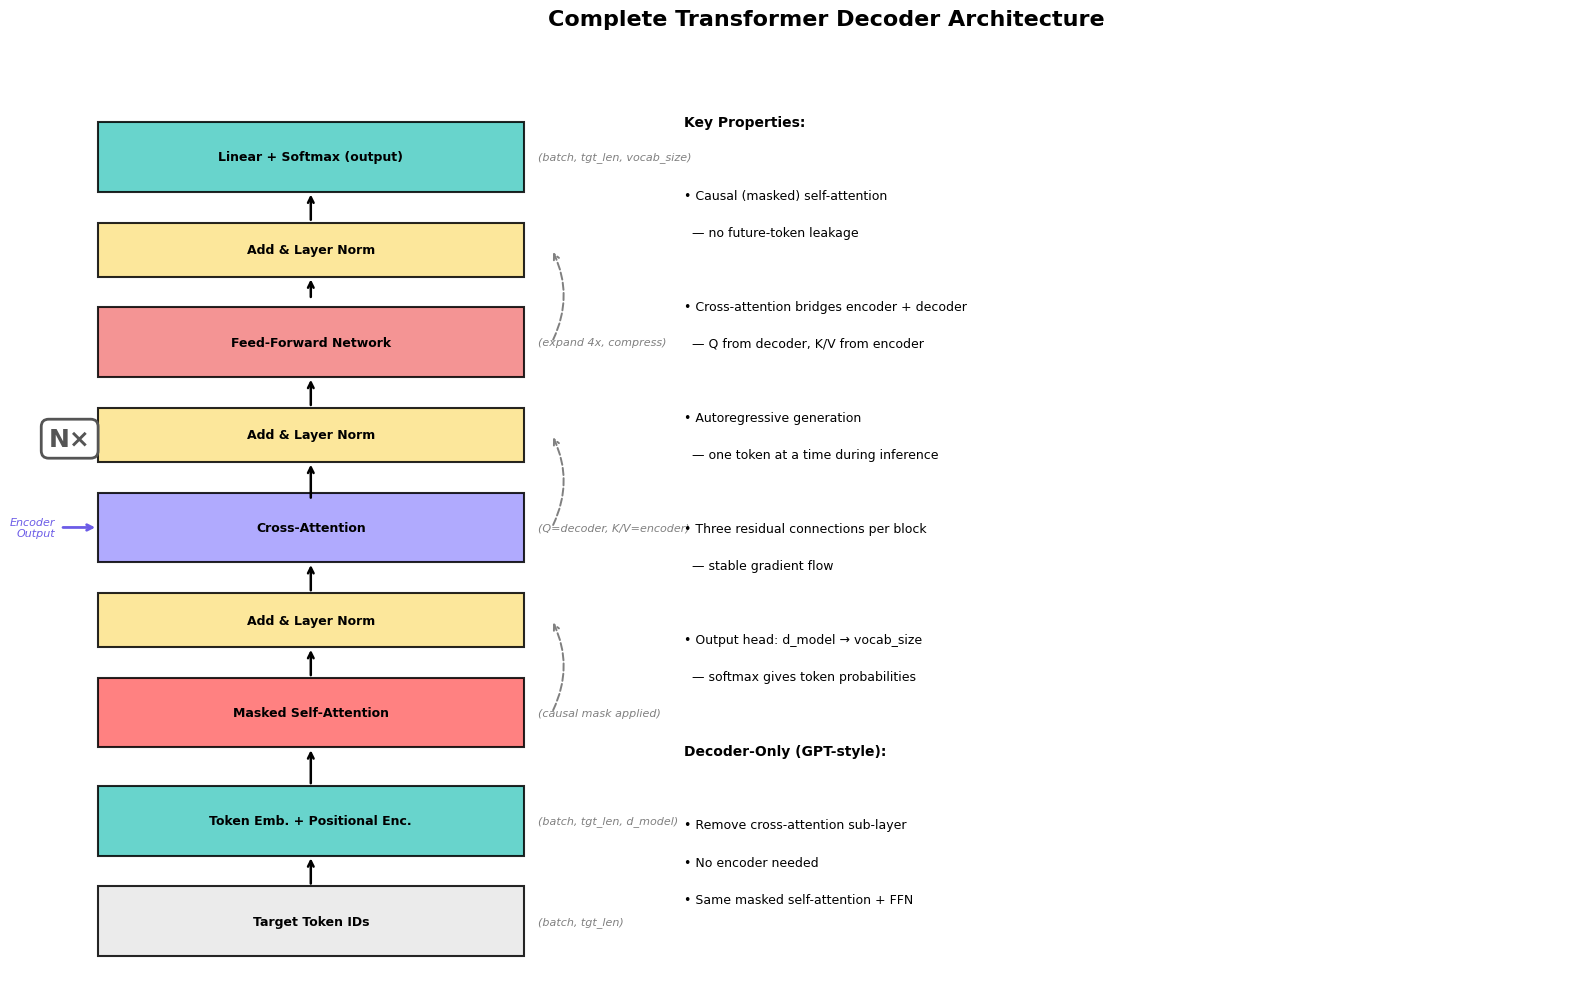

In [31]:
fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 12)
ax.axis("off")
ax.set_title("Complete Transformer Decoder Architecture", fontsize=16, fontweight="bold", pad=20)

# ── Left: Full Decoder ───────────────────────────────────────────────────
blocks = [
    (0.3, 0.3,  4.5, 0.9, "Target Token IDs",              "#E8E8E8", "(batch, tgt_len)"),
    (0.3, 1.6,  4.5, 0.9, "Token Emb. + Positional Enc.",  "#4ECDC4", "(batch, tgt_len, d_model)"),
    (0.3, 3.0,  4.5, 0.9, "Masked Self-Attention",         "#FF6B6B", "(causal mask applied)"),
    (0.3, 4.3,  4.5, 0.7, "Add & Layer Norm",              "#FCE38A", ""),
    (0.3, 5.4,  4.5, 0.9, "Cross-Attention",               "#A29BFE", "(Q=decoder, K/V=encoder)"),
    (0.3, 6.7,  4.5, 0.7, "Add & Layer Norm",              "#FCE38A", ""),
    (0.3, 7.8,  4.5, 0.9, "Feed-Forward Network",          "#F38181", "(expand 4x, compress)"),
    (0.3, 9.1,  4.5, 0.7, "Add & Layer Norm",              "#FCE38A", ""),
    (0.3, 10.2, 4.5, 0.9, "Linear + Softmax (output)",     "#4ECDC4", "(batch, tgt_len, vocab_size)"),
]

for x, y, w, h, label, color, shape_text in blocks:
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor="black", linewidth=1.5, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=9, fontweight="bold")
    if shape_text:
        ax.text(x + w + 0.15, y + h/2, shape_text, ha="left", va="center",
                fontsize=8, color="gray", fontstyle="italic")

# Arrows: main flow
for y0, y1 in [(1.2, 1.6), (2.5, 3.0), (3.9, 4.3), (5.0, 5.4),
               (6.2, 6.7), (7.4, 7.8), (8.8, 9.1), (9.8, 10.2)]:
    ax.annotate("", xy=(2.55, y1), xytext=(2.55, y0),
                arrowprops=dict(arrowstyle="->", lw=1.8, color="black"))

# Residual skip connections
for y0, y1 in [(3.0, 4.3), (5.4, 6.7), (7.8, 9.1)]:
    ax.annotate("", xy=(5.1, y1 + 0.35), xytext=(5.1, y0 + 0.45),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.4,
                               connectionstyle="arc3,rad=0.25", linestyle="--"))

# Encoder memory arrow
ax.annotate("", xy=(0.3, 5.85), xytext=(-0.1, 5.85),
            arrowprops=dict(arrowstyle="->", color="#6C5CE7", lw=2))
ax.text(-0.15, 5.85, "Encoder\nOutput", ha="right", va="center",
        fontsize=8, color="#6C5CE7", fontstyle="italic")

# Nx label
ax.text(0.0, 7.0, "N×", fontsize=18, fontweight="bold", color="#555",
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#555", linewidth=2))

# ── Right: Key Properties ────────────────────────────────────────────────
props = [
    ("Key Properties:", True),
    ("", False),
    ("• Causal (masked) self-attention", False),
    ("  — no future-token leakage", False),
    ("", False),
    ("• Cross-attention bridges encoder + decoder", False),
    ("  — Q from decoder, K/V from encoder", False),
    ("", False),
    ("• Autoregressive generation", False),
    ("  — one token at a time during inference", False),
    ("", False),
    ("• Three residual connections per block", False),
    ("  — stable gradient flow", False),
    ("", False),
    ("• Output head: d_model → vocab_size", False),
    ("  — softmax gives token probabilities", False),
    ("", False),
    ("Decoder-Only (GPT-style):", True),
    ("", False),
    ("• Remove cross-attention sub-layer", False),
    ("• No encoder needed", False),
    ("• Same masked self-attention + FFN", False),
]

for i, (text, bold) in enumerate(props):
    ax.text(6.5, 11.2 - i * 0.48, text,
            fontsize=10 if bold else 9,
            fontweight="bold" if bold else "normal",
            va="top")

plt.tight_layout()
plt.show()

### Key Takeaways

- The **Transformer Decoder** generates output sequences **token by token**, using the encoder's memory as context
- It introduces two critical new ideas over the encoder:
  1. **Causal masking** — ensures the model cannot see future tokens during training or inference
  2. **Cross-attention** — lets the decoder dynamically focus on relevant parts of the encoder output
- Each decoder block has **three sub-layers** (vs. two in the encoder):
  1. Masked Multi-Head Self-Attention
  2. Cross-Attention
  3. Feed-Forward Network
- The **decoder-only** variant (GPT, LLaMA) removes cross-attention and is trained purely on next-token prediction
- **Autoregressive generation** feeds previously generated tokens back as input, one step at a time
- The decoder is the foundation of models like **GPT** (decoder-only), and the seq-to-seq side of **T5**, **BART**, and the original **Transformer** for machine translation

In [32]:
# Print the full model architectures
print("=" * 60)
print("FULL TRANSFORMER DECODER")
print("=" * 60)
print(decoder)
print()
print("=" * 60)
print("GPT-STYLE DECODER-ONLY")
print("=" * 60)
print(gpt)

FULL TRANSFORMER DECODER
TransformerDecoder(
  (token_embedding): Embedding(1000, 64)
  (pos_encoding): SinusoidalPositionalEncoding()
  (dropout): Dropout(p=0.1, inplace=False)
  (layers): ModuleList(
    (0-3): 4 x DecoderBlock(
      (self_attn): MaskedMultiHeadSelfAttention(
        (W_q): Linear(in_features=64, out_features=64, bias=True)
        (W_k): Linear(in_features=64, out_features=64, bias=True)
        (W_v): Linear(in_features=64, out_features=64, bias=True)
        (W_o): Linear(in_features=64, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (cross_attn): CrossAttention(
        (W_q): Linear(in_features=64, out_features=64, bias=True)
        (W_k): Linear(in_features=64, out_features=64, bias=True)
        (W_v): Linear(in_features=64, out_features=64, bias=True)
        (W_o): Linear(in_features=64, out_feature

### Comparison: Original Transformer Decoder vs Our Implementation

| Component | Original Paper | Our Implementation |
|-----------|---------------|--------------------|
| d_model | 512 | 64 |
| num_heads | 8 | 4 |
| d_ff | 2048 | 256 |
| num_layers | 6 | 4 |
| Positional Encoding | Sinusoidal | Sinusoidal |
| Self-Attention | Masked (causal) | Masked (causal) |
| Cross-Attention | Yes | Yes |
| Normalization | Post-norm | Post-norm |
| Dropout | 0.1 | 0.1 |

- Our implementation follows the **exact same architecture** as the original, just with smaller dimensions for demonstration purposes
- To scale up: increase `d_model`, `num_heads`, `d_ff`, and `num_layers`
- To build a GPT-style model: use `GPTDecoder` — remove the encoder and cross-attention